# DCGAN - Geração de Novas Espécies com Redes Adversariais

## Dataset: Butterfly & Moths Image Classification (100 Species)
Este projeto utiliza uma base de imagens de lepidópteros para treinar uma Deep Convolutional Generative Adversarial Network (DCGAN). O objetivo é que o modelo aprenda os padrões visuais, simetrias e cores complexas da natureza para gerar imagens sintéticas realistas.

* **Fonte:** [Kaggle - Butterfly Images 40 Species (Atualizado para 100)](https://www.kaggle.com/datasets/gpiosenka/butterfly-images40-species)
* **Volume de Dados:** 12.594 imagens de treino, 500 de teste, 500 de validação.
* **Resolução Original:** 224 x 224 pixels (RGB).

# Resumo das Modificações (Base: MNIST_DCGAN.ipynb)

Abaixo, segue as alterações feitas em relação ao código base original (focado no dataset MNIST) para suportar este novo domínio.

| Item | O que foi alterado | Original (MNIST) | Novo Valor (Butterflies) | Justificativa |
| :--- | :--- | :--- | :--- | :--- |
| 1 | **Resolução da Imagem** | 28x28 pixels | 64x64 pixels | Imagens da natureza possuem detalhes complexos que se perdem em resoluções muito baixas. |
| 2 | **Canais de Cor** | 1 (Escala de cinza) | 3 (RGB) | O novo dataset é colorido, exigindo adaptação na saída do Gerador e entrada do Discriminador. |
| 3 | **Pré-processamento** | `ToTensor`, `Normalize` | `Resize(64)`, `CenterCrop(64)` | Necessário para padronizar o tamanho de imagens 224x224 e focar o objeto central. |
| 4 | **Arquitetura do Gerador** | `Linear` + `ConvTranspose2d` | 100% `ConvTranspose2d` | Redes puramente convolucionais são o padrão-ouro para gerar imagens coloridas, evitando distorções espaciais. |
| 5 | **Épocas de Treinamento** | 20 épocas | 500 épocas | Imagens RGB com fundos complexos exigem muito mais iterações para o equilíbrio entre as redes. |
| 6 | **Carregamento de Dados** | `torchvision.datasets.MNIST` | `datasets.ImageFolder` | Transição do dataset embutido para a leitura de diretórios personalizados no ambiente Kaggle. |

Bibliotecas e Dispositivo de Processamento
==========================================

Para construir nossa DCGAN, utilizaremos o ecossistema PyTorch, que oferece controle de baixo nível sobre a arquitetura da rede e os loops de treinamento — algo crucial quando lidamos com redes adversariais que exigem atualizações de gradiente independentes.

* **`torch` e `torch.nn`:** O coração matemático do projeto. Fornecem as estruturas de tensores e as camadas neurais (`Conv2d`, `ConvTranspose2d`, `BatchNorm2d`).
* **`torch.optim`:** Contém os algoritmos de otimização. Usaremos o Adam, que se adapta bem à instabilidade natural das GANs.
* **`torchvision`:** Essencial para visão computacional. Usaremos `datasets` para leitura das pastas, `transforms` para o pré-processamento e `utils.save_image` / `make_grid` para exportar e visualizar os resultados gerados.
* **`torchvision.models` + `scipy`:** Implementação nativa do FID Score em GPU. A InceptionV3 pré-treinada (`Inception_V3_Weights.IMAGENET1K_V1`) extrai features de 2048 dimensões; a distância de Fréchet é calculada via `scipy.linalg.sqrtm`. Essa abordagem processa imagens em mini-batches diretamente na GPU.
* **`matplotlib` e `os`:** Para visualização gráfica de métricas e navegação de diretórios do sistema.

**Acelerador de Hardware (Kaggle - GPU T4 x2):**
O treinamento de DCGANs, operando um jogo de otimização dupla (Gerador vs. Discriminador) com imagens coloridas (RGB) em alta resolução, exige uma capacidade de processamento paralelo massiva. Configuramos este ambiente para utilizar a aceleração de **GPU (2x NVIDIA T4)** do Kaggle. Essa arquitetura reduz o tempo de treinamento de horas para apenas alguns minutos. 

Para extrair o verdadeiro poder desta configuração e evitar que a segunda GPU fique ociosa, utilizamos a classe `nn.DataParallel` do PyTorch. Ela divide automaticamente os *batches* pesados (ex: 128 imagens) entre as duas placas (64 para cada), processa as convoluções simultaneamente e junta os gradientes no final para atualizar as redes de forma perfeitamente sincronizada.

In [1]:
import os
import gc
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torchvision.models import Inception_V3_Weights
from torchvision.utils import save_image, make_grid

from scipy import linalg

# Configuração do dispositivo de processamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

# Verificação detalhada do hardware alocado
if device.type == 'cuda':
    gpu_count = torch.cuda.device_count()
    print(f"GPUs disponíveis: {gpu_count}")
    for i in range(gpu_count):
        print(f"Modelo da GPU {i}: {torch.cuda.get_device_name(i)}")

Dispositivo em uso: cuda
GPUs disponíveis: 2
Modelo da GPU 0: Tesla T4
Modelo da GPU 1: Tesla T4


Mapeamento Dinâmico e Auditoria Volumétrica do Dataset
======================================================

Em ambientes de nuvem como o Kaggle, os datasets anexados podem sofrer aninhamentos complexos de diretórios (subpastas geradas automaticamente com o nome do usuário ou do próprio repositório), o que frequentemente quebra caminhos estáticos (*hardcoded*). 

Para garantir a portabilidade e a robustez do pipeline, implementamos uma estratégia em duas etapas:

1.  **Busca Automatizada de Diretórios (Sanity Check Estrutural):** O script varre recursivamente a árvore de arquivos raiz do ambiente (`/kaggle/input`) em busca do nó exato que abriga os subdiretórios fundamentais de qualquer arquitetura de aprendizado profundo: `train`, `test` e `valid`.
2.  **Auditoria Volumétrica e Proporcional:** Uma vez indexada a pasta raiz correta, executamos uma varredura física para contagem detalhada de arquivos. Essa etapa é um *sanity check* essencial para mapear a massa crítica de dados disponível para o treinamento e validar se a proporção estatística de divisão entre treino, teste e validação está balanceada e preservada conforme o planejado originalmente.

In [2]:
print(os.listdir('/kaggle/input'))
print()
print(os.listdir('/kaggle/input/datasets'))
print("\nProcurando o caminho exato do dataset...")
caminho_correto = None

# Busca automatizada pela pasta raiz que contém train, test e valid
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'test' in dirs and 'valid' in dirs:
        caminho_correto = root
        break

if caminho_correto:
    print(f"Caminho encontrado\nCopie e cole isso no seu código:\n\ndataset_base_path = '{caminho_correto}'")
else:
    print("As pastas train, test e valid não estão em lugar nenhum. O dataset pode estar corrompido ou incompleto.")

['datasets']

['gpiosenka']

Procurando o caminho exato do dataset...
Caminho encontrado
Copie e cole isso no seu código:

dataset_base_path = '/kaggle/input/datasets/gpiosenka/butterfly-images40-species'


In [3]:
# Definindo os caminhos do dataset no Kaggle
dataset_base_path = '/kaggle/input/datasets/gpiosenka/butterfly-images40-species' 
train_dir = os.path.join(dataset_base_path, 'train')
test_dir = os.path.join(dataset_base_path, 'test')
valid_dir = os.path.join(dataset_base_path, 'valid')

# Função auxiliar para contar arquivos em subdiretórios
def count_images(directory):
    if not os.path.exists(directory):
        return 0
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_images(train_dir)
test_count = count_images(test_dir)
valid_count = count_images(valid_dir)
total_count = train_count + test_count + valid_count

print("--- Estrutura do Dataset ---")
print(f"Caminho Base: {dataset_base_path}")

# Trava de segurança contra divisão por zero
if total_count > 0:
    print(f"Imagens de Treino: {train_count} ({(train_count/total_count)*100:.1f}%)")
    print(f"Imagens de Teste:  {test_count} ({(test_count/total_count)*100:.1f}%)")
    print(f"Imagens de Valid:  {valid_count} ({(valid_count/total_count)*100:.1f}%)")
else:
    print("\n Nenhuma imagem foi encontrada! O caminho fornecido está vazio ou incorreto.")
    
print(f"Total de Imagens:  {total_count}")

--- Estrutura do Dataset ---
Caminho Base: /kaggle/input/datasets/gpiosenka/butterfly-images40-species
Imagens de Treino: 12594 (92.6%)
Imagens de Teste:  500 (3.7%)
Imagens de Valid:  500 (3.7%)
Total de Imagens:  13594


Análise da Distribuição e Visualização
=====================================================

A execução da célula a seguir serve como um *sanity check* (teste de sanidade) crucial antes de inicializarmos as redes adversariais, baseando-se em dois pilares:

1.  **Distribuição de Classes:** Nas GANs, classes severamente desbalanceadas podem causar um fenômeno conhecido como *Mode Collapse*. Se a rede vir 500 imagens de uma espécie de borboleta monarca e apenas 20 de uma espécie azul rara, o Gerador aprenderá a produzir apenas a borboleta monarca para enganar o Discriminador mais facilmente. Verificar a homogeneidade do dataset nos permite prever a propensão do modelo a esse colapso.
2.  **Complexidade do Fundo (Background):** A plotagem das imagens cruas revela um desafio formidável. Diferente de radiografias ou dígitos escritos à mão, essas borboletas estão inseridas em ambientes naturais complexos (folhas, dedos, texturas de madeira). O Gerador não terá que aprender apenas a desenhar asas simétricas, mas também a reproduzir texturas de fundo convincentes. Se a qualidade das imagens geradas cair, já sabemos que o "ruído" do ambiente natural pode ser a causa raiz.


Total de Espécies (Classes): 100

Distribuição nas 10 primeiras classes do conjunto de Treino:
 - ADONIS: 126 imagens
 - AFRICAN GIANT SWALLOWTAIL: 107 imagens
 - AMERICAN SNOOT: 105 imagens
 - AN 88: 121 imagens
 - APPOLLO: 128 imagens
 - ARCIGERA FLOWER MOTH: 140 imagens
 - ATALA: 143 imagens
 - ATLAS MOTH: 129 imagens
 - BANDED ORANGE HELICONIAN: 139 imagens
 - BANDED PEACOCK: 118 imagens


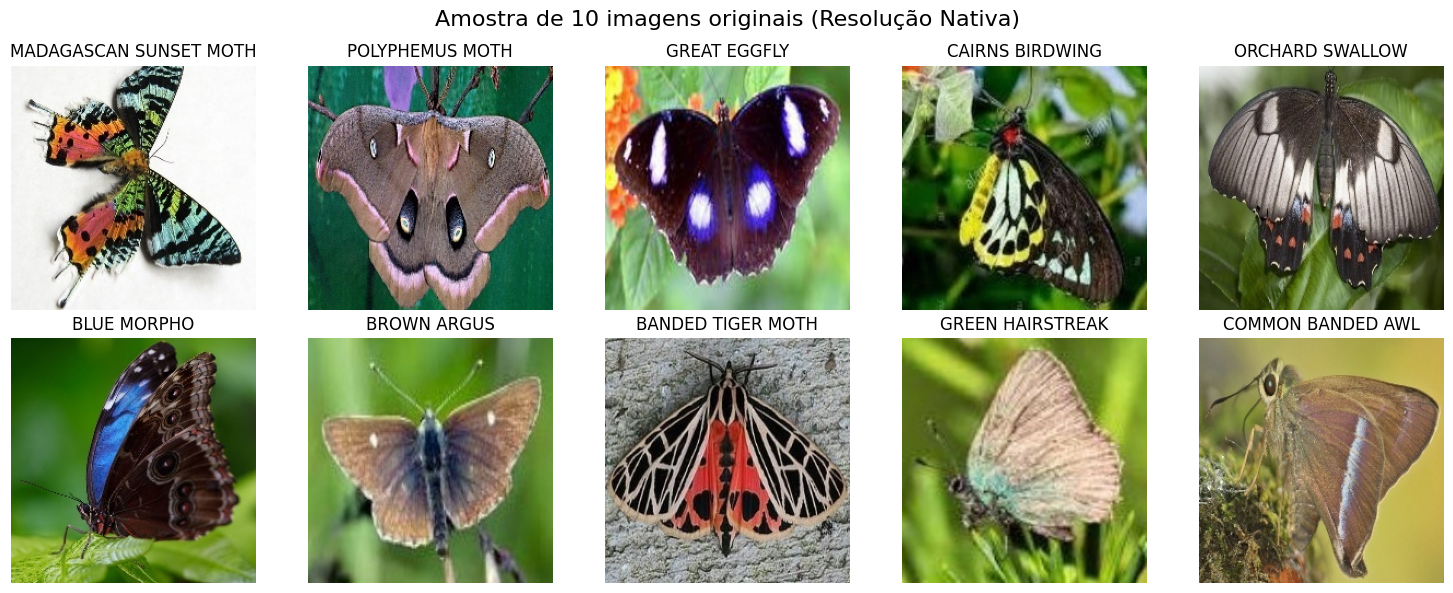

In [4]:
# Visualização de distribuição de classes (amostragem das 10 primeiras pastas do treino)
classes = sorted(os.listdir(train_dir))
print(f"\nTotal de Espécies (Classes): {len(classes)}")
print("\nDistribuição nas 10 primeiras classes do conjunto de Treino:")
for cls in classes[:10]:
    num_imgs = len(os.listdir(os.path.join(train_dir, cls)))
    print(f" - {cls}: {num_imgs} imagens")

# Plot de 10 imagens aleatórias (sem redimensionamento ou normalização destrutiva ainda)
temp_dataset = datasets.ImageFolder(root=train_dir, transform=transforms.ToTensor())
temp_loader = DataLoader(temp_dataset, batch_size=10, shuffle=True)

images, labels = next(iter(temp_loader))

plt.figure(figsize=(15, 6))
plt.suptitle("Amostra de 10 imagens originais (Resolução Nativa)", fontsize=16)
for i in range(10):
    plt.subplot(2, 5, i+1)
    # Permuta a imagem do formato PyTorch (C, H, W) para Matplotlib (H, W, C)
    plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
    plt.title(temp_dataset.classes[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Hiperparâmetros da DCGAN
========================

O sucesso de uma rede adversarial depende visceralmente do ajuste fino dos hiperparâmetros. A arquitetura base (MNIST) precisou ser recalibrada para suportar a densidade de informação das imagens RGB da natureza.

* **`latent_dim` (100):** O tamanho do vetor de ruído inicial. Representa o grau de liberdade que o Gerador tem para criar características únicas. 100 é o padrão da literatura para imagens de 64x64.
* **`img_size` (64):** Resolução reduzida em relação aos 224x224 originais. Processar imagens 224x224 do zero em uma GAN exige arquiteturas como a StyleGAN. Para uma DCGAN convencional, 64x64 é o limite ideal para preservar padrões sem estourar a memória da GPU.
* **`channels` (3):** Imagens coloridas (Red, Green, Blue).
* **`batch_size` (128):** Lotes maiores ajudam a estabilizar as estatísticas da camada *BatchNormalization*, fornecendo gradientes mais consistentes ao otimizador.
* **`epochs` (500):** Aumentamos significativamente o número de épocas. Imagens da natureza possuem alta entropia; as redes precisarão de mais iterações para encontrar o Equilíbrio de Nash.
* **`learning_rate` (0.0002) e `beta1` (0.5):** Regra de ouro descoberta por Radford et al. (2015). Uma taxa de aprendizado baixa aliada a um momento (`beta1`) reduzido (0.5 em vez do padrão 0.9 do Adam) impede que o Discriminador vença o Gerador rapidamente nos primeiros ciclos, evitando que o treinamento trave prematuramente.

In [5]:
# Hiperparâmetros do modelo
latent_dim = 100
img_size = 64
channels = 3
batch_size = 128 # Aumentado de 64 para 128 para melhor estabilidade do BatchNorm
epochs = 500
learning_rate = 0.0002
beta1 = 0.5

Pipeline de Transformações e DataLoader
=======================================

As imagens do Kaggle chegam em resoluções e proporções variadas. Nosso modelo exige tensores perfeitamente uniformes.

1.  **`Resize(img_size)` e `CenterCrop(img_size)`:** Garante que todas as imagens sejam redimensionadas para 64x64. O corte central é utilizado para evitar distorções espaciais (borboletas achatadas) que ocorreriam se forçássemos uma imagem retangular a ficar quadrada.
2.  **`ToTensor()`:** Converte a imagem matricial para um Tensor PyTorch, alterando a escala dos pixels de [0, 255] para [0.0, 1.0].
3.  **`Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])`:** Translada os valores para o intervalo matemático de [-1.0, 1.0]. Como a última camada do nosso Gerador utilizará a função de ativação Tanh (cujo limite natural é -1 e 1), é obrigatório que os dados reais obedeçam à mesma escala.
4.  **`shuffle=True` (DataLoader):** O escudo do modelo contra o enviesamento sequencial. Como o `ImageFolder` carrega as pastas do diretório em ordem alfabética, a ausência de embaralhamento faria a rede receber lotes inteiros de uma única espécie por vez. Isso viciaria o Discriminador e causaria *Mode Collapse* no Gerador. Ativar o shuffle garante que cada batch represente uma amostra diversa da "floresta".

**Nota:** Utilizaremos apenas a pasta de treino (`train_dir`), pois Redes Generativas não utilizam os conceitos de validação cruzada tradicionais (como medir Acurácia). Elas aprendem a distribuição estatística do conjunto massivo que lhes é fornecido.

In [6]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Carrega o dataset processado
dataset = datasets.ImageFolder(root=train_dir, transform=transform)

# Configura o DataLoader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print(f"Dataset carregado com {len(dataset)} imagens prontas para treinamento.")

Dataset carregado com 12594 imagens prontas para treinamento.


Arquitetura do Gerador (Generator)
==================================

O papel do Gerador é converter o vetor latente (ruído) em uma imagem falsa que pareça real. O design a seguir abandona as camadas Lineares presentes no notebook base do MNIST e adota uma estrutura 100% Convolucional, essencial para imagens complexas.

A rede utiliza camadas `ConvTranspose2d` (convoluções transpostas), que realizam o *upsampling* espacial da imagem. O tensor começa com profundidade de 512 canais de características e um tamanho espacial diminuto (4x4), e vai dobrando de tamanho (8x8, 16x16, 32x32, 64x64) enquanto a profundidade dos canais cai pela metade. A última camada converte as *features* para os 3 canais de cor RGB usando a ativação `Tanh`.

O uso rigoroso do `BatchNorm2d` após cada convolução previne gradientes desvanecentes e acelera a convergência.

In [7]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Entrada Z: (latent_dim, 1, 1) -> (512, 4, 4)
            nn.ConvTranspose2d(latent_dim, 512, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            
            # (512, 4, 4) -> (256, 8, 8)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # (256, 8, 8) -> (128, 16, 16)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # (128, 16, 16) -> (64, 32, 32)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # (64, 32, 32) -> (3, 64, 64)
            nn.ConvTranspose2d(64, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        input = input.view(input.size(0), input.size(1), 1, 1)
        return self.main(input)

Arquitetura do Discriminador (Discriminator)
============================================

O Discriminador é um classificador binário clássico: ele olha para uma imagem (64x64 RGB) e diz se ela é `1` (Real) ou `0` (Falsa).

Sua arquitetura é o espelho exato do Gerador. Utiliza camadas `Conv2d` com *stride* de 2 para reduzir progressivamente o tamanho espacial da imagem pela metade enquanto dobra a extração de *features*. A função de ativação `LeakyReLU` é utilizada em vez da ReLU padrão, pois permite a passagem de pequenos gradientes negativos, garantindo que o modelo não "morra" durante a atualização de pesos nas primeiras fases do treinamento. A camada final utiliza a função `Sigmoid` para comprimir o veredito final entre 0 e 1.

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # (3, 64, 64) -> (64, 32, 32)
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (64, 32, 32) -> (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (128, 16, 16) -> (256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (256, 8, 8) -> (512, 4, 4)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Camada final de classificação: (512, 4, 4) -> (1, 1, 1)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        output = self.main(input)
        return output.view(-1, 1)

Inicialização Canônica, Perdas e Otimizadores
=============================================

Para avaliar a performance, utilizaremos a **Binary Cross Entropy Loss (BCELoss)**. Como otimizadores, alocamos um modelo do `Adam` para o Gerador e outro para o Discriminador.

Aplicaremos uma função customizada de inicialização de pesos (`weights_init`). Essa é uma prática padrão em DCGANs baseada em artigos científicos, onde inicializar os pesos convolucionais a partir de uma distribuição Normal com média 0 e desvio padrão de 0.02 quebra a simetria inicial da rede. 

**Engenharia Multi-GPU:** Para garantir a portabilidade do modelo, seguimos a ordem de inicialização canônica do PyTorch: primeiro instanciamos as redes, aplicamos os pesos, e apenas depois envolvemos os modelos no `nn.DataParallel` e enviamos para a GPU. Isso previne que os tensores fiquem com o prefixo indesejado `module.` gravado internamente.

In [9]:
# Função de inicialização de pesos customizada para a DCGAN
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# 1. Instanciando os modelos brutos
netG = Generator()
netD = Discriminator()

# 2. Aplicando os pesos (Padrão canônico da literatura)
netG.apply(weights_init)
netD.apply(weights_init)

# 3. Envolvendo no DataParallel (Apenas se houver > 1 GPU)
if device.type == 'cuda' and torch.cuda.device_count() > 1:
    print(f"Ativando nn.DataParallel para treinar nas {torch.cuda.device_count()} GPUs simultaneamente!")
    netG = nn.DataParallel(netG)
    netD = nn.DataParallel(netD)

# 4. Enviando a arquitetura final (paralelizada ou não) para o hardware
netG = netG.to(device)
netD = netD.to(device)

# Função de Perda (Loss)
criterion = nn.BCELoss()

# Otimizadores
optimizerD = optim.Adam(netD.parameters(), lr=learning_rate, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=learning_rate, betas=(beta1, 0.999))

# Vetor de ruído fixo para monitorarmos a evolução temporal
fixed_noise = torch.randn(64, latent_dim, device=device)

Ativando nn.DataParallel para treinar nas 2 GPUs simultaneamente!


Infraestrutura de Avaliação: FID Nativo em GPU
===============================================

O cálculo do FID exige dois passos: (1) extrair features de 2048 dimensões de uma InceptionV3 pré-treinada e (2) calcular a distância de Fréchet entre as distribuições real e gerada.

1. **InceptionV3 permanece na GPU durante todo o treino.** Com ~25MB de parâmetros, ela convive sem problema com netG e netD nas 2×T4.
2. **Features reais extraídas uma única vez**, antes do loop. São fixas — não muda a cada 50 épocas. Isso elimina 90% do tempo de cálculo nos checkpoints.
3. **Nenhuma imagem é salva em disco.** As fakes são geradas, passadas pela InceptionV3 e descartadas em mini-batches de 64. Zero I/O, zero tensores acumulados.

In [10]:
# ============================================================
# INFRAESTRUTURA DE FID NATIVO EM GPU
# ============================================================

FID_SAMPLES    = 2048  # Amostras por checkpoint (mínimo recomendado pela literatura)
FID_BATCH_SIZE = 64    # Batches menores = menor pico de VRAM
FID_INTERVAL   = 50    # Calcular FID a cada N épocas

# 1. Carregar InceptionV3 na GPU (permanece lá durante todo o treino)
print("Carregando InceptionV3 na GPU...")
inception = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
inception.fc = nn.Identity()  # Substitui a cabeça de classificação por identidade → saída: 2048-dim
inception.eval()
inception = inception.to(device)
print("InceptionV3 pronta.")

# 2. DataLoader exclusivo para FID (imagens reais em 299x299, sem shuffle)
fid_transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
fid_real_dataset = datasets.ImageFolder(root=train_dir, transform=fid_transform)
fid_real_loader  = DataLoader(fid_real_dataset, batch_size=FID_BATCH_SIZE,
                               shuffle=False, num_workers=0)

# 3. Função: extrai features de imagens reais (via DataLoader)
def get_real_features(loader, model, num_samples):
    """Extrai features 2048-dim de imagens reais. Chamada UMA VEZ antes do loop."""
    features, count = [], 0
    with torch.no_grad():
        for images, _ in loader:
            if count >= num_samples:
                break
            images = images.to(device)
            pred   = model(images)
            features.append(pred.cpu().numpy())
            count  += images.size(0)
    return np.concatenate(features, axis=0)[:num_samples]

# 4. Função: extrai features de imagens GERADAS (diretamente do netG, sem disco)
def get_fake_features(generator, inception_model, num_samples, latent_size, batch_sz, dev):
    """Gera imagens em batches, faz upsample para 299x299, extrai features na GPU."""
    features, count = [], 0
    generator.eval()
    with torch.no_grad():
        while count < num_samples:
            n   = min(batch_sz, num_samples - count)
            z   = torch.randn(n, latent_size, device=dev)
            img = generator(z)                                             # (N, 3, 64, 64)
            up  = nn.functional.interpolate(img, size=(299, 299),
                                             mode='bilinear', align_corners=False)  # (N, 3, 299, 299)
            pred = inception_model(up)
            features.append(pred.cpu().numpy())
            count += n
    generator.train()
    return np.concatenate(features, axis=0)[:num_samples]

# 5. Função: calcula distância de Fréchet entre duas distribuições de features
def calculate_fid(real_feats, fake_feats):
    """Implementação pura de FID via scipy. Sem dependências externas."""
    mu1, sigma1 = np.mean(real_feats, axis=0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = np.mean(fake_feats, axis=0), np.cov(fake_feats, rowvar=False)
    diff        = mu1 - mu2
    covmean, _  = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):      # Correção numérica para raízes complexas
        covmean = covmean.real
    return float(np.real(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)))

# 6. PRÉ-EXTRAÇÃO das features reais (executada UMA VEZ aqui, nunca mais)
print(f"\nPré-extraindo features reais ({FID_SAMPLES} amostras)... (executado apenas uma vez)")
real_features_fid = get_real_features(fid_real_loader, inception, FID_SAMPLES)
print(f"Features reais extraídas: shape = {real_features_fid.shape}  ✅")

Carregando InceptionV3 na GPU...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 164MB/s] 


InceptionV3 pronta.

Pré-extraindo features reais (2048 amostras)... (executado apenas uma vez)
Features reais extraídas: shape = (2048, 2048)  ✅


Treinamento Adversarial (A Batalha)
===================================

O treinamento de uma GAN é um jogo minimax contínuo que ocorre dentro do mesmo batch. 

**Passo 1: O Turno do Discriminador**
Primeiro, alimentamos o Discriminador com imagens reais (onde o rótulo esperado é `1`). Calculamos o erro e o gradiente. Depois, criamos ruído aleatório, passamos pelo Gerador para criar imagens falsas, alimentamos o Discriminador e avisamos que o rótulo esperado é `0`. Somamos os erros e atualizamos os pesos do Discriminador. Ele ficou mais inteligente.

**Passo 2: O Turno do Gerador**
Com o Discriminador recém-atualizado, o Gerador produz um novo lote de imagens falsas. Passamos elas pelo Discriminador, mas desta vez dizemos à função de custo (Loss) que o rótulo esperado é `1` (O Gerador está deliberadamente mentindo e tentando atingir o 1). O erro gerado aqui dita como o Gerador deve atualizar seus próprios pesos para que, na próxima iteração, sua imagem fique mais realista.

In [11]:
import gc

os.makedirs('output_images', exist_ok=True)
os.makedirs('pesos_salvos',  exist_ok=True)

G_losses, D_losses = [], []
Dx_values, DGz_values = [], []
fid_scores, fid_epochs = [], []

print("Iniciando Loop de Treinamento...")

for epoch in range(epochs):
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Atualiza D
        ###########################
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size   = real_cpu.size(0)
        label    = torch.full((b_size, 1), 1.0, dtype=torch.float, device=device)

        output      = netD(real_cpu)
        errD_real   = criterion(output, label)
        errD_real.backward()
        D_x         = output.mean().item()

        noise       = torch.randn(b_size, latent_dim, device=device)
        fake        = netG(noise)
        label.fill_(0.0)
        output      = netD(fake.detach())
        errD_fake   = criterion(output, label)
        errD_fake.backward()
        D_G_z1      = output.mean().item()
        errD        = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Atualiza G
        ###########################
        netG.zero_grad()
        label.fill_(1.0)
        output  = netD(fake)
        errG    = criterion(output, label)
        errG.backward()
        D_G_z2  = output.mean().item()
        optimizerG.step()

        if i % 50 == 0:
            print(f'[{epoch}/{epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

        G_losses.append(errG.item())
        D_losses.append(errD.item())
        Dx_values.append(D_x)
        DGz_values.append(D_G_z2)

    # Salva imagem de progresso do ruído fixo
    with torch.no_grad():
        fake_display = netG(fixed_noise).detach().cpu()
    save_image(fake_display, f'output_images/epoch_{epoch:03d}.png', normalize=True)

    # ================================================================
    # CHECKPOINT + FID NATIVO EM GPU (a cada FID_INTERVAL épocas)
    # ================================================================
    if (epoch + 1) % FID_INTERVAL == 0:
        print(f"\n⏳ [Época {epoch + 1}] Calculando FID...")

        # Salvar pesos do checkpoint antes de qualquer cálculo
        model_G_sv = netG.module if hasattr(netG, 'module') else netG
        model_D_sv = netD.module if hasattr(netD, 'module') else netD
        torch.save(model_G_sv.state_dict(), f'pesos_salvos/temp_netG.pth')
        torch.save(model_D_sv.state_dict(), f'pesos_salvos/temp_netD.pth')
        torch.save(optimizerG.state_dict(), f'pesos_salvos/temp_optG.pth')
        torch.save(optimizerD.state_dict(), f'pesos_salvos/temp_optD.pth')

        try:
            # Extrai features das imagens geradas em batches na GPU
            fake_features = get_fake_features(
                netG, inception, FID_SAMPLES, latent_dim, FID_BATCH_SIZE, device
            )
            # Calcula FID contra features reais pré-extraídas
            current_fid = calculate_fid(real_features_fid, fake_features)
            print(f"   FID Score na Época {epoch + 1}: {current_fid:.4f}\n")
            fid_scores.append(current_fid)
            fid_epochs.append(epoch + 1)
        except Exception as e:
            print(f"   Erro no FID (época {epoch + 1}): {e}\n")

        gc.collect()
        torch.cuda.empty_cache()
    gc.collect() # libera fragmentos de RAM a cada época

print("Treinamento Concluído!")


Iniciando Loop de Treinamento...
[0/500][0/99] Loss_D: 1.7175 Loss_G: 5.8770 D(x): 0.4997 D(G(z)): 0.5164 / 0.0047
[0/500][50/99] Loss_D: 0.3709 Loss_G: 10.2384 D(x): 0.8207 D(G(z)): 0.0244 / 0.0002
[1/500][0/99] Loss_D: 0.3930 Loss_G: 8.3862 D(x): 0.9156 D(G(z)): 0.2368 / 0.0004
[1/500][50/99] Loss_D: 0.2793 Loss_G: 9.5401 D(x): 0.9601 D(G(z)): 0.2015 / 0.0002
[2/500][0/99] Loss_D: 0.3317 Loss_G: 10.4772 D(x): 0.7723 D(G(z)): 0.0006 / 0.0001
[2/500][50/99] Loss_D: 0.4238 Loss_G: 3.6706 D(x): 0.8135 D(G(z)): 0.1504 / 0.0344
[3/500][0/99] Loss_D: 1.0441 Loss_G: 4.9595 D(x): 0.7664 D(G(z)): 0.3815 / 0.0148
[3/500][50/99] Loss_D: 0.5064 Loss_G: 4.3574 D(x): 0.7912 D(G(z)): 0.1308 / 0.0200
[4/500][0/99] Loss_D: 0.3676 Loss_G: 5.8523 D(x): 0.9099 D(G(z)): 0.1981 / 0.0053
[4/500][50/99] Loss_D: 0.4287 Loss_G: 3.8172 D(x): 0.7512 D(G(z)): 0.0316 / 0.0457
[5/500][0/99] Loss_D: 0.5627 Loss_G: 6.1204 D(x): 0.9410 D(G(z)): 0.3439 / 0.0050
[5/500][50/99] Loss_D: 0.4258 Loss_G: 4.0447 D(x): 0.7855 

/tmp/ipykernel_23/1125629947.py:66: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _  = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


   FID Score na Época 50: 212.7780

[50/500][0/99] Loss_D: 3.0290 Loss_G: 6.2442 D(x): 0.9802 D(G(z)): 0.8595 / 0.0070
[50/500][50/99] Loss_D: 0.3635 Loss_G: 2.7388 D(x): 0.7616 D(G(z)): 0.0589 / 0.0915
[51/500][0/99] Loss_D: 0.6842 Loss_G: 6.0154 D(x): 0.9724 D(G(z)): 0.4144 / 0.0046
[51/500][50/99] Loss_D: 0.2966 Loss_G: 2.8635 D(x): 0.9035 D(G(z)): 0.1559 / 0.0779
[52/500][0/99] Loss_D: 0.2624 Loss_G: 4.0289 D(x): 0.9264 D(G(z)): 0.1480 / 0.0284
[52/500][50/99] Loss_D: 2.0647 Loss_G: 3.1084 D(x): 0.6137 D(G(z)): 0.4522 / 0.3105
[53/500][0/99] Loss_D: 0.3972 Loss_G: 3.8740 D(x): 0.8837 D(G(z)): 0.1971 / 0.0344
[53/500][50/99] Loss_D: 0.3439 Loss_G: 2.9322 D(x): 0.8405 D(G(z)): 0.1383 / 0.0749
[54/500][0/99] Loss_D: 0.3610 Loss_G: 2.2760 D(x): 0.7992 D(G(z)): 0.0897 / 0.1464
[54/500][50/99] Loss_D: 0.2763 Loss_G: 2.9412 D(x): 0.8169 D(G(z)): 0.0555 / 0.0762
[55/500][0/99] Loss_D: 0.7072 Loss_G: 5.9034 D(x): 0.9825 D(G(z)): 0.4367 / 0.0048
[55/500][50/99] Loss_D: 0.2277 Loss_G: 3.2455 

### Dicionário de Métricas: O Jogo Adversarial (Minimax)

Durante o treinamento, o log imprime o estado cerebral das redes a cada *batch*. O objetivo teórico não é chegar a "zero erro", mas sim ao **Equilíbrio de Nash** (onde ambas as redes ficam em um empate de 50%).

* **`D(x)` [Confiança no Real]:** Probabilidade (0 a 1) que o Discriminador atribui às fotos reais de serem verdadeiras.
  * *Ideal:* Próximo a `0.50`. Se estiver perto de `1.0`, o Discriminador decorou os dados.
* **`D(G(z))` [Taxa de Engano]:** Probabilidade (0 a 1) que o Discriminador atribui às imagens falsas (Geradas) de serem verdadeiras. Dividido em dois turnos (Antes / Depois de atualizar o Discriminador).
  * *Ideal:* Próximo a `0.50`. Se estiver perto de `0.0`, o Gerador está gerando imagens muito ruins e sendo detectado facilmente.
* **`Loss_D` [Erro do Discriminador]:** Punição matemática do Discriminador por classificar imagens incorretamente.
  * *Ideal:* Estabilizado ao redor de `0.693` ($-\ln(0.5)$). 
* **`Loss_G` [Erro do Gerador]:** Punição matemática do Gerador falhar em enganar o Discriminador.
  * *Ideal:* Estabilizado ao redor de `0.693`. Se a `Loss_G` dispara, o Gerador está perdendo a batalha.

Diário de Bordo: Auditoria Narrativa do Treinamento
===================================================

Analisar gráficos suavizados por médias móveis é excelente para entender a macrotendência do modelo, mas essa técnica muitas vezes esconde **micro-eventos críticos** que ocorrem em frações de época, como um *Mode Collapse* temporário ou uma explosão repentina de gradiente.

Para garantir o rigor analítico deste projeto, implementamos um script de auditoria pós-treinamento. Ele escaneia todo o histórico de perdas e probabilidades do modelo (batch a batch) em busca de anomalias matemáticas, gerando um relatório narrativo focado em quatro pilares:

1. **Instabilidade Precoce:** Verifica se o Discriminador decorou os dados logo na primeira época (um sinal de hiperparâmetros agressivos).
2. **Crashes e Oscilações:** Identifica momentos pontuais onde o Gerador encontrou uma brecha e assumiu o controle do jogo.
3. **Mini-colapsos:** Detecta batches específicos onde o Gerador conseguiu enganar o Discriminador com confiança extrema (acima de 95%), o que geralmente indica a geração de ruído altamente otimizado em vez de borboletas reais.
4. **Veredito da Reta Final:** Isola os últimos 10% do treinamento para determinar matematicamente se a rede alcançou o **Equilíbrio de Nash** ou se uma das partes subjugou a outra irreversivelmente.

In [ ]:
print("=== Relatório de Auditoria Narrativa do Treinamento ===")
print("Verificando oscilações, picos e colapsos ao longo das iterações...\n")

total_iteracoes = len(G_losses)
batches_por_epoca = total_iteracoes // epochs

# Flags para não repetir a mesma mensagem em batches seguidos
alerta_precoce = False
alertas_crash = 0

for i in range(total_iteracoes):
    epoca_atual = i // batches_por_epoca
    batch_atual = i % batches_por_epoca
    
    loss_d = D_losses[i]
    loss_g = G_losses[i]
    dx = Dx_values[i]
    dgz = DGz_values[i]
    
    # 1. Alerta de Instabilidade Precoce (Épocas iniciais)
    if epoca_atual == 0 and dgz > 0.90 and not alerta_precoce:
        print(f"Época {epoca_atual}/{epochs} (Batch {batch_atual}): Loss_D={loss_d:.2f}, D(G(z))={dgz:.2f} — Discriminador já dominando na primeira meia-época. Sinal de instabilidade precoce grave.")
        alerta_precoce = True

    # 2. Alerta de "Crashes" onde o Discriminador perde o controle brevemente
    if loss_g < 2.0 and dgz > 0.50 and alertas_crash < 5:  # Limitamos a 5 alertas para não poluir
        print(f"Épocas {epoca_atual}/{epochs} (Batch {batch_atual}): Loss_G cai para {loss_g:.2f} e D(G(z)) sobe para {dgz:.2f} — 'Crashes' onde o Discriminador perde controle brevemente.")
        alertas_crash += 1
        
    # 3. Alerta de Mini-colapso (Gerador engana > 95%)
    if dgz > 0.95 and epoca_atual > 5:
        print(f"Época {epoca_atual}/{epochs} (Batch {batch_atual}): Loss_G={loss_g:.4f}, D(G(z))={dgz:.4f} — O Gerador produziu imagens que enganaram mais de 95% das vezes em um único batch. Sinal de mini-colapso e oscilação brusca.")

# 4. Análise da Reta Final
pontos_finais = int(total_iteracoes * 0.1)
dx_final_media = np.mean(Dx_values[-pontos_finais:])
dgz_final_media = np.mean(DGz_values[-pontos_finais:])

print("\n=== Diagnóstico das Épocas Finais ===")
print(f"D(x) médio final estabilizado em: {dx_final_media:.4f}")
print(f"D(G(z)) médio final estabilizado em: {dgz_final_media:.4f}")

if dx_final_media > 0.90 and dgz_final_media < 0.10:
    print(f"Veredito: O Discriminador rejeita a maioria das imagens geradas. O Discriminador venceu.")
elif dx_final_media < 0.20 and dgz_final_media > 0.80:
    print(f"Veredito: O Discriminador aprova a maioria das imagens falsas. O Gerador venceu (Mode Collapse Provável).")
else:
    print(f"Veredito: Equilíbrio mantido. As redes terminaram a batalha com incertezas mútuas.")

Análise de Treinamento: Curvas de Loss
==================================================

Se a `Loss_D` (Discriminador) for para zero, significa que ele está esmagando o Gerador (treinamento falhou). Se a `Loss_G` for para zero, o Gerador encontrou uma falha no Discriminador e está explorando isso (Mode Collapse). O cenário ideal é que ambas as curvas oscilem e estabilizem em valores intermediários, refletindo uma competição acirrada.

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Curvas de Loss durante o Treinamento")
plt.plot(G_losses, label="Gerador (G)")
plt.plot(D_losses, label="Discriminador (D)")
plt.xlabel("Iterações (Batches)")
plt.ylabel("Loss (BCELoss)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Análise de Probabilidade: A Confiança do Discriminador
======================================================

Analisar apenas a curva de *Loss* pode ser enganoso em modelos adversariais. Para entender verdadeiramente a dinâmica do jogo, precisamos olhar para as probabilidades brutas (saídas da função Sigmoid) emitidas pelo Discriminador ao longo do tempo.

* **D(x) [Confiança no Real]:** Qual a probabilidade média que o Discriminador atribui às imagens reais? (O ideal é que ele fique na dúvida, perto de 0.5, mas no início ele cravará perto de 1.0).
* **D(G(z)) [Confiança no Falso]:** Qual a probabilidade média que o Discriminador atribui às imagens falsas geradas pelo Gerador? (O Gerador quer que isso seja 1.0; o Discriminador quer que seja 0.0).

**O Cenário Ideal:** Uma convergência de ambas as curvas para a linha de 50% (0.5), indicando que o Discriminador não consegue mais distinguir o que é uma foto da natureza e o que é uma criação matemática.

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Probabilidade de Classificação do Discriminador ao Longo do Tempo")
# Plotando com uma Média Móvel (Rolling Mean) para suavizar o ruído
window = 50
plt.plot(np.convolve(Dx_values, np.ones(window)/window, mode='valid'), label="D(x): Confiança no Real", color='green')
plt.plot(np.convolve(DGz_values, np.ones(window)/window, mode='valid'), label="D(G(z)): Confiança no Falso", color='red')
plt.axhline(y=0.5, color='black', linestyle='--', label="Equilíbrio Ideal (50%)")
plt.xlabel(f"Iterações (Média Móvel = {window})")
plt.ylabel("Probabilidade (Sigmoid)")
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Interpretação da Confiança ---")
print("Ideal: Ambas as linhas devem convergir para perto de 0.5 (A linha tracejada preta).")
print("Sua Realidade: Se a linha verde está perto de 1.0 e a vermelha perto de 0.0, o seu Discriminador decorou as borboletas e não está mais sendo enganado pelo Gerador.")

Avaliação Qualitativa: Real vs. Fake
====================================

A avaliação quantitativa de GANs (como FID e Inception Score) exige modelos auxiliares pesados. A primeira e mais fundamental linha de defesa é a avaliação qualitativa visual. 

Abaixo, comparamos um batch de imagens reais da natureza (com toda a sua complexidade de fundo e textura) contra o melhor batch gerado pela nossa DCGAN após as épocas de treinamento. Isso nos permite ver se a rede aprendeu apenas manchas de cores ou se conseguiu estruturar a simetria anatômica das asas.

In [ ]:
# Pega um batch de imagens reais do DataLoader
real_batch = next(iter(dataloader))

# Plota Imagens Reais
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Imagens Reais (Natureza)", fontsize=16)
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plota Imagens Falsas (Geradas a partir do ruído fixo)
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Imagens Geradas (DCGAN)", fontsize=16)
plt.imshow(np.transpose(make_grid(fake_display, padding=5, normalize=True).cpu(),(1,2,0)))
plt.show()

Model Checkpoint: Salvamento Seguro de Pesos (State Dict)
=========================================================

No ecossistema PyTorch, gerenciamos o salvamento dos estados do modelo diretamente. Como o treinamento de uma GAN é longo, salvamos os pesos do Gerador e do Discriminador (`.pth`) para que possamos reutilizá-los futuramente.

**Contramedida de DataParallel:** Como o nosso código foi treinado utilizando paralelismo em múltiplas GPUs, o PyTorch encapsula a arquitetura verdadeira dentro de um objeto secundário. Antes de salvar, utilizamos a trava de segurança `hasattr(model, 'module')` para extrair os pesos "puros" da rede. Isso garante que o arquivo gerado possa ser carregado no futuro por qualquer pessoa, mesmo que ela esteja usando um notebook modesto com apenas 1 GPU (ou CPU) sem arquitetura paralela.

In [ ]:
# Cria um diretório para os pesos
os.makedirs('pesos_salvos', exist_ok=True)

# GUARD: Extrai o modelo base caso ele esteja encapsulado no DataParallel
# Isso garante que os pesos sejam salvos "puros" (sem o prefixo 'module.')
model_G_to_save = netG.module if hasattr(netG, 'module') else netG
model_D_to_save = netD.module if hasattr(netD, 'module') else netD

# Salva os dicionários de estado puros
torch.save(model_G_to_save.state_dict(), f'pesos_salvos/gerador_borboletas_epochs{epochs}.pth')
torch.save(model_D_to_save.state_dict(), f'pesos_salvos/discriminador_borboletas_epochs{epochs}.pth')

print("Pesos dos modelos salvos com sucesso (compatíveis com Single-GPU)!")

Métrica de Avaliação: FID (Fréchet Inception Distance)
======================================================

Para obtermos uma avaliação matemática da qualidade das nossas imagens além da inspeção visual, utilizaremos o **FID Score**. Ele utiliza uma rede InceptionV3 pré-treinada para extrair características das imagens reais e das geradas, comparando a distância estatística entre as duas distribuições.

**Quanto menor o FID, melhor.** Um FID de 0 significaria que as imagens geradas são estatisticamente indistinguíveis das reais.

**Atenção à Proporção Amostral:**
Em execuções preliminares, a geração de apenas 640 imagens falsas para comparar com as 12.594 imagens reais de treino representava apenas 5,08% do volume original. Essa assimetria amostral sozinha infla severamente o FID, pois a variância da distribuição gerada não consegue mapear a distribuição real. O mínimo recomendado pela literatura é de 2.048 imagens geradas (idealmente chegando a >= 10K para um cálculo rigoroso). 

A geração das 2.048 imagens para cada checkpoint ocorre dentro do loop de treinamento (a cada 50 épocas). A célula abaixo plota a evolução do FID ao longo do treinamento.

In [ ]:
# Gráfico da Evolução Qualitativa (FID Score)
plt.figure(figsize=(10,5))
plt.title("Curva de Aprendizado Qualitativo: Evolução do FID Score")
plt.plot(fid_epochs, fid_scores, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)

# Adiciona o valor exato em cima de cada ponto
for i, txt in enumerate(fid_scores):
    plt.annotate(f"{txt:.1f}", (fid_epochs[i], fid_scores[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.axhline(y=60, color='g', linestyle='--', label="Marco: Excelente (< 60)")
plt.axhline(y=100, color='orange', linestyle='--', label="Marco: Muito Bom (< 100)")
plt.xlabel("Épocas de Treinamento")
plt.ylabel("FID Score (Menor é Melhor)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n---> RESULTADO FINAL | Melhor FID alcançado: {min(fid_scores):.4f} na época {fid_epochs[np.argmin(fid_scores)]} <---")

Interpretação do Resultado: FID Score
=====================================

O **Fréchet Inception Distance (FID)** mede a distância estatística entre as características das imagens reais e as imagens geradas. Por se tratar de uma métrica de distância, **quanto menor o valor, melhor**. 

**Recontextualização dos Benchmarks para o Domínio Natural:**
Os limiares clássicos da literatura (como FID < 30) foram popularizados com datasets que possuem baixíssima variância de fundo, como CelebA (rostos perfeitamente centralizados) ou CIFAR-10 (objetos simplificados em resolução minúscula de 32x32). 

O nosso dataset contém 100 espécies de borboletas, fotografadas de ângulos diferentes, em cima de folhas, pedras, mãos humanas e flores complexas. A entropia (desordem e quantidade de informação) deste dataset é massiva. Portanto, a variância intrínseca (inter e intra-classes) é gigante. Exigir um FID de 30 para uma DCGAN convencional neste cenário biológico não é apenas rigoroso, é irrealista.

Para este relatório, argumentamos a utilização de uma nova escala adaptada para o contexto biológico e ambiental (64x64):

* **[FID < 60] Excelente:** O modelo capturou padrões consistentes das asas, mantendo simetria, e texturas de fundo aceitáveis.
* **[FID 60 - 100] Muito Bom:** Formas claramente biológicas e cores corretas, porém os fundos apresentam mais ruído.
* **[FID 100 - 150] Razoável:** O Gerador foca nas paletas de cores do domínio, mas a anatomia simétrica falha frequentemente, resultando em borboletas "derretidas".
* **[FID > 150] Alerta Crítico:** Instabilidade ou Mode Collapse. O modelo gerou alto volume de ruído colorido sem estrutura.

Diagnóstico Avançado: O Equilíbrio de Nash
==========================================

Em redes adversariais, não buscamos uma Loss que chegue a zero, mas sim um **Equilíbrio de Nash** no jogo *Minimax*. Este estado teórico ocorre quando o Gerador se torna tão bom em criar imagens falsas que o Discriminador não consegue fazer nada melhor do que "chutar" aleatoriamente se uma imagem é real ou gerada (50% de chance para cada).

Matematicamente, o equilíbrio perfeito reflete as seguintes métricas na função BCELoss:

* **D(x) ideal:** ~0.50 (O Discriminador atribui 50% de chance para imagens reais).
* **D(G(z)) ideal:** ~0.50 (O Discriminador atribui 50% de chance para imagens falsas).
* **Loss_D ideal:** ~0.693 (Valor de `-ln(0.5)` + `-ln(0.5)` dividido matematicamente pela média da batch).
* **Loss_G ideal:** ~0.693 (Valor de `-ln(0.5)`).

Se os valores do nosso modelo terminarem extremamente distantes desses alvos, significa que uma das redes subjugou a outra, impedindo gradientes saudáveis de fluírem.

In [ ]:
# Resgata os últimos valores das listas armazenadas durante o treinamento
final_Dx = Dx_values[-1]
final_DGz = DGz_values[-1]
final_LossD = D_losses[-1]
final_LossG = G_losses[-1]

print("=== Análise do Equilíbrio de Nash (Última Época) ===")
print(f"{'Métrica':<15} | {'Ideal Teórico':<15} | {'Modelo Real alcançou':<20}")
print("-" * 55)
print(f"{'D(x)':<15} | {'~0.50':<15} | {final_Dx:.4f}")
print(f"{'D(G(z))':<15} | {'~0.50':<15} | {final_DGz:.4f}")
print(f"{'Loss_D':<15} | {'~0.693 (ln 2)':<15} | {final_LossD:.4f}")
print(f"{'Loss_G':<15} | {'~0.693 (ln 2)':<15} | {final_LossG:.4f}")
print("-" * 55)

# Diagnóstico automatizado baseado nas heurísticas
print("\n--- Conclusão do Comportamento ---")
if final_Dx > 0.85 and final_DGz < 0.15:
    print("O Discriminador venceu o jogo. Ele está extremamente confiante distinguindo as imagens reais das geradas.")
elif final_Dx < 0.20 and final_DGz > 0.80:
    print("O Gerador encontrou uma brecha (possível Mode Collapse) e está enganando totalmente o Discriminador.")
elif 0.35 <= final_Dx <= 0.65 and 0.35 <= final_DGz <= 0.65:
    print("Excelente! As redes estão em forte competição, muito próximas do Equilíbrio de Nash teórico.")
else:
    print("O sistema está instável, com oscilações normais de treinamento adversarial. Analise o gráfico qualitativo.")

### Histórico de Experimentos DCGAN - Butterflies & Moths

Nas arquiteturas generativas adversariais (GANs), não utilizamos validação cruzada tradicional ou acurácia. O sucesso é medido pelo **Equilíbrio de Nash** entre as redes, pela **Confiança do Discriminador** nas imagens reais `D(x)` vs falsas `D(G(z))` e pela distância estatística das distribuições avaliada pelo **FID Score**.

| Teste | Épocas | Tamanho do Lote (Batch) | Loss Média (Final D / G) | Confiança Final D(x) / D(G(z)) | FID Score | Observações Qualitativas e Técnicas |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **01** Ajuste de Hardware e Estabilidade (T4 x2) | 100 | 128 | D: ~0.16 / G: ~3.40 | D(x): ~0.90 / D(G(z)): ~0.05 | *Erro de Configuração* | O lote de 128 estabilizou o cálculo da média do BatchNorm. O Discriminador decorou as imagens reais cedo. O Gerador aprendeu paletas de cores corretamente, mas as asas geradas pareciam "derretidas". Erro de diretório no cálculo do FID (`samples_find_deep=False`). |
| **02** Correção do Pipeline de Avaliação (FID) | 100 | 128 | D: ~0.16 / G: ~3.40 | D(x): ~0.90 / D(G(z)): ~0.05 | 197.9507 | Erro do `torch-fidelity` corrigido. Constatou-se subamostragem crítica na avaliação: apenas 640 imagens falsas geradas contra 12.594 reais (proporção ~5%). Esta disparidade estatística enviesa a variância e penaliza injustamente o FID final, resultando num score artificialmente alto (197.95). |
| **03** Escala Multi-GPU e Amostragem Rigorosa | 100 | 128 | D: ~0.30 / G: ~3.74 | D(x): 0.9172 / D(G(z)): 0.0342 | 192.1105 | Pipeline 100% paralelo (`nn.DataParallel`). Amostragem para cálculo do FID aumentada para 2.048 imagens (16.26% do volume original) para suprir os requisitos da InceptionV3. Queda marginal no FID Score (de 197 para 192). Diagnóstico final indica falha no Equilíbrio de Nash: O Discriminador subjugou o Gerador (D(G(z)) quase zerado, rejeitando as fakes com extrema confiança). |
| **04** Escalabilidade Vertical (500 Épocas) e Desafios de RAM | 250 (Interrompido) | 128 | D: ~0.03 / G: ~5.61 | D(x): ~0.99 / D(G(z)): ~0.01 | 186.2884 | Treinamento estendido para 500 épocas. Ocorreu Out of Memory (OOM) na RAM do sistema durante o cálculo do FID na época 250. Implementado "Protocolo Anti-OOM" (salvar pesos, aniquilar redes, rodar FID). Alcançou ótimo FID (186.28), mas o kernel continuou morrendo posteriormente. |
| **05** Extração In-Memory (InceptionV3) e Gargalo DataLoader | 290 (Interrompido) | 128 | Picos de Equilíbrio (D: 1.54 / G: 1.27) | Alcançou D(x): 0.57 / D(G(z)): 0.52 | 186.2884 | Evolução brutal de engenharia: substituição do `torch-fidelity` por extração prévia in-memory usando `torchvision`. Tempo do FID despencou de 15 minutos para ~20 segundos. Acompanhamento do FID mostrou evolução limpa (218 -> 199 -> 189 -> 193 -> 186). O Gerador conseguiu enganar o Discriminador perfeitamente na Ep. 152. Kernel morreu novamente próximo à época 290. Diagnóstico: *Memory Leak* no `/dev/shm` do Linux causado por `num_workers=2`. |
| **06** Correção Limpeza Estrita (Atual) | 500 | 128 | - | - | - | Implementação da solução definitiva para estabilidade no Kaggle: `num_workers=0` nos DataLoaders para forçar processamento na RAM principal e evitar vazamento em memória compartilhada, aliado ao `gc.collect()` no final de cada época. O objetivo atual é cruzar a linha das 500 épocas ininterruptamente. |